In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv", encoding = "latin- 1")
df = df[['v1' ,'v2' ]]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '',text)
    return text

In [5]:
df['message'] = df['message'].apply(clean_text)
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])

In [7]:
df['label'] = df['label'].map({'ham' : 0, 'spam' : 1})
y = df['label']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [9]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [10]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_pred = model.predict(X_test)
print('Accuracy Score :', accuracy_score(y_test,y_pred))


Accuracy Score : 0.967713004484305


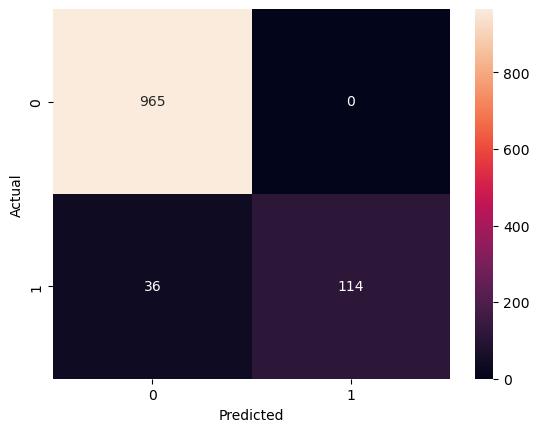

In [11]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
sample_sms = [ "Congratulations! You have won 10000 cash prize", "Bro are you coming college today"]
sample_sms_clean = [ clean_text(sms) for sms in sample_sms ]
sample_sms_vec = vectorizer.transform(sample_sms_clean)
predictions = model.predict(sample_sms_vec)
for sms, pred in zip(sample_sms,predictions):
    print(sms, "->", "SPAM" if pred==1 else "HAM")

Congratulations! You have won 10000 cash prize -> SPAM
Bro are you coming college today -> HAM


In [13]:
user_sms = input("Enter ans SMS")
user_sms_clean = clean_text(user_sms)
user_sms_vec = vectorizer.transform([user_sms_clean])
prediction = model.predict(user_sms_vec)

if prediction[0]==1 :
    print("SPAM Message")
else :
    print("HAM Message")    

HAM Message
